# 0. Set up 

Run the following cell to ensure all dependencies are satisfied and the APOGEE allStar catalog (which we'll use later on) is downloaded.

In [1]:
import setup as s
from setup import * 
file_path = './tess_data/'

Installing dependencies...
Done!
Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


# 1. Let's look at some light curves 
I've built a function called tess_data_download that takes in the parameters <code>num_obj</code>, <code>order_random</code>, <code>target_index</code>, and <code>search_radius</code>. If no parameters are inputted, light curves for 4680 exoplanets in <a href = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TD" > NASA's table of transiting exoplanets </a>. 

The parameters are as follows: 
<p style="text-indent: 50px;">
<code>num_obj</code>: Tells the function to only download a certain number of objects. 
<p style="text-indent: 50px;">
<code>order_random</code>: If set to False (default) the objects will be ordered in sequential order from the table. Otherwise, objects will be randomly selected from the table
<p style="text-indent: 50px;">
<code>target_index</code>: Selects the index of a specific object you want from the table
<p style="text-indent: 50px;">
<code>search_radius</code>: Defaults to 0.1 arcseconds and determines the radius a TESS detection must fall from the planet's radius to be considered a valid match
</p>

In [2]:
# to download the first five objects from the table 
s.tess_data_download(num_obj = 5)

mkdir: tess_data: File exists


File has already been downloaded
Previous file kept
File has already been downloaded
Previous file kept
File has already been downloaded
Previous file kept
No source found.
Now trying BD+05 4868 A b
File has already been downloaded
Previous file kept
File has already been downloaded
Previous file kept


Now, let's choose one object to work through the TESS data for. You can always come back and look through the data for the other objects later. 

In [16]:
target_obj = 'AU_Mic_b'
target_file_path = file_path+target_obj
lightcurve_files = s.glob.glob(s.os.path.join(target_file_path, '*'))

<code> lightcurve_files </code> now contains the locations of all the TESS lightcurves we retrieved for 55 Cne e. 

We can look at just one:

Text(0, 0.5, 'Flux (erg/cm$^2$/s)')

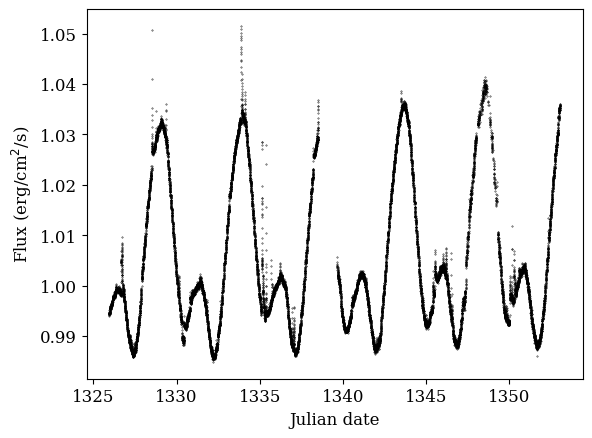

In [17]:
hdu_list = fits.open(lightcurve_files[0], memmap=True)
data = Table(hdu_list[1].data)
# remove data that is flagged as being high quality and data that does not have a value
mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX'])) 
data_filtered = data[mask]
plt.scatter(data['TIME'], data['PDCSAP_FLUX']/np.nanmedian(data['PDCSAP_FLUX']),color = 'k', s= 0.1)
plt.xlabel('Julian date')
plt.ylabel(r'Flux (erg/cm$^2$/s)')

It's hard to tell <em> anything </em> from this plot! To get around this, we can move to frequency-space. However, you'll notice that applying the familiar Fourier transform won't work here. This is because transits do not exhibit sinusoidal shapes, making Fourier transforms an ineffectual method of detecting them. To get around this, we can use the Box Least Squares (BLS) method, which is conceptually similar to a Fourier transform, but models the transit as a "downward box" rather than a sine wave. 

We'll use <code> astropy</code>'s <code>BoxLeastSquares</code> function. 

But, do this, we'll want multiple transits which we can't detect in a single observation unless the orbital period of the planet is less than 13.5 Earth days (TESS typically observes a given star for 27 days). 

Good thing we have multiple observations! Let's merge all of our times, fluxes, and flux errors for each observation into a single list 

In [36]:
time = []
flux = []
fluxerr = []
for file in lightcurve_files: 
    hdu_list = fits.open(file, memmap=True)
    data = Table(hdu_list[1].data)
    
    #repeat our filtering process 
    mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX']))
    data_filtered = data[mask]
    time = list(data['TIME'])
    flux = list(data['PDCSAP_FLUX'])
    flux_normalized = flux/np.nanmedian(flux)
    fluxerr = list(data['PDCSAP_FLUX_ERR'])
    fluxerr_normalized = fluxerr/np.nanmedian(fluxerr)
    time.extend(time)
    flux.extend(flux_normalized)
    fluxerr.extend(fluxerr_normalized)


Now, let's fit this with a BLS model.

You can find the documentation for these functions <a href ="https://docs.astropy.org/en/stable/timeseries/bls.html"> here</a>.

In [38]:
# remove any nan values just to be safe
m = np.isnan(flux) | np.isnan(fluxerr)
flux = np.array(flux)[~m]
fluxerr=np.array(fluxerr)[~m]
time = np.array(time)[~m]

In [39]:
model = BoxLeastSquares(np.array(time) * u.day, np.array(flux), dy= np.array(fluxerr))
durations = np.linspace(0.05, 0.2, 10) * u.day
results = model.autopower(durations, frequency_factor=5.0)

We can now plot a "periodogram" 

Text(0, 0.5, 'log likelihood')

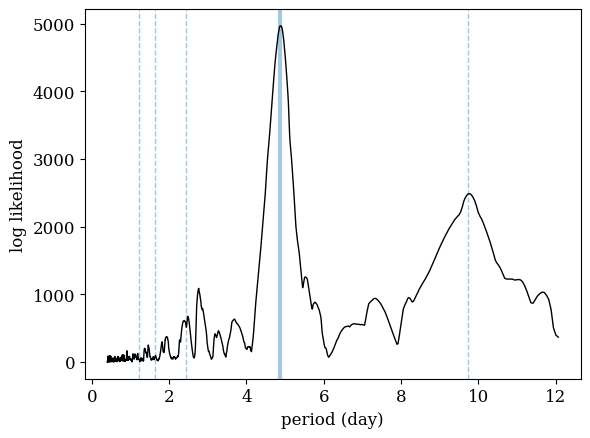

In [51]:

period = results.period[np.argmax(results.power)]
plt.axvline(period.value, alpha=0.4, lw=3)
for n in range(2, 5):
    pos_harmonic = n*period.value
    neg_harmonic= period.value / n
    if(pos_harmonic <= np.max((results.period).value)): 
        plt.axvline(n*period.value, alpha=0.4, lw=1, linestyle="dashed")
    if(neg_harmonic >= np.min((results.period).value)):
        plt.axvline(period.value / n, alpha=0.4, lw=1, linestyle="dashed")
plt.plot(results.period, results.power, color = 'k')
plt.xlabel("period (day)")
plt.ylabel("log likelihood")

In [ ]:

files = sd.glob.glob('tess_data/*')
files = [f[10:].replace("_", " ") for f in files]
name = transiting_exo['pl_name'][0]
if(name in files): 
    print("True")

In [ ]:
f = f[10:]
f=f.replace("_", " ")

In [ ]:
f

In [ ]:
bool()

In [ ]:
name = transiting_exo['pl_name'][0]


In [ ]:
sd.tess_data_download(num_obj=5)